<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIoT_RF_Book_ES_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELLA 1
# ============================================================================
# KEYWORD SPOTTING CON DISTILLAZIONE E TESTING
# ============================================================================

# ========================================
# 📦 Installazione pacchetti necessari
# ========================================
!pip install -q tensorflow tensorflow-hub librosa matplotlib scikit-learn seaborn ipywidgets
# ========================================
# 📚 Import delle librerie
# ========================================
import tensorflow as tf  # Framework di machine learning principale
import tensorflow_hub as hub  # Per caricare modelli pre-addestrati da TensorFlow Hub
import numpy as np  # Libreria per operazioni matematiche su array
import librosa  # Libreria specializzata per l'analisi audio
import matplotlib.pyplot as plt  # Per creare grafici e visualizzazioni
import os  # Per operazioni sul file system
import random  # Per operazioni casuali (mescolamento dataset)
from sklearn.metrics import classification_report, confusion_matrix  # Metriche di valutazione
from sklearn.model_selection import train_test_split  # Per dividere il dataset
import seaborn as sns  # Libreria per visualizzazioni statistiche avanzate
from tensorflow.keras import layers, Model  # Componenti per costruire reti neurali
from tensorflow.keras.optimizers import Adam  # Ottimizzatore Adam per il training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Callback per controllo training

# ============================================================================
# ⚙️ CONFIGURAZIONE PARAMETRI GLOBALI
# ============================================================================
# Definizione dei parametri generali per il preprocessing e il training

SAMPLE_RATE = 16000           # Frequenza di campionamento audio
DURATION = 1.0                # Durata dell'audio in secondi
N_SAMPLES = int(SAMPLE_RATE * DURATION)  # Numero di campioni totali per clip audio
BATCH_SIZE = 32               # Dimensione batch per il training
EPOCHS = 25                   # Numero di epoche
LEARNING_RATE = 0.001         # Tasso di apprendimento iniziale
NUM_CLASSES = 2               # Numero di classi da classificare
CLASSES = ['yes', 'no']       # Etichette delle classi target

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.8 MB/s eta 0:00:00


In [ ]:
# CELLA 2
# ========================================
# 📥 Download e suddivisione dataset
# ========================================
# Scarica il dataset da TF e lo divide in training, validation e test

dataset_url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"  # URL del dataset Google Speech Commands
# Scarica il dataset, lo estrae e lo salva nella cartella data
data_dir = tf.keras.utils.get_file(
    'speech_commands_v0.02', dataset_url, extract=True, cache_dir='.', cache_subdir='data')
data_dir = data_dir.replace('.tar.gz', '')  # Rimuove l'estensione per ottenere il percorso della cartella

all_files, all_labels = [], []  # Liste per memorizzare percorsi file e relative etichette
# Itera attraverso ogni classe definita (yes, no)
for i, class_name in enumerate(CLASSES):
    class_dir = os.path.join(data_dir, class_name)  # Costruisce il percorso della cartella della classe
    files = [f for f in os.listdir(class_dir) if f.endswith('.wav')]  # Trova tutti i file .wav nella cartella
    print(f"Trovati {len(files)} file per la classe '{class_name}'")  # Stampa il numero di file trovati
    # Aggiunge ogni file alle liste con la sua etichetta numerica
    for file in files:
        all_files.append(os.path.join(class_dir, file))  # Percorso completo del file
        all_labels.append(i)  # Etichetta numerica (0 per 'yes', 1 per 'no')

combined = list(zip(all_files, all_labels))  # Combina file e etichette in coppie
random.shuffle(combined)  # Mescola casualmente le coppie per evitare bias
all_files, all_labels = zip(*combined)  # Separa nuovamente file e etichette dopo il mescolamento

# Prima divisione: 70% training, 30% temporaneo (validation + test)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
# Seconda divisione: dividi il 30% in 20% validation e 10% test
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=1/3, stratify=temp_labels, random_state=42)

# ========================================
# 📊 Analisi composizione dataset (Aggiunta)
# ========================================
print("\n" + "="*50)
print("📊 COMPOSIZIONE DATASET")
print("="*50)

# Analizza la distribuzione delle classi nel training set
train_yes = sum(1 for label in train_labels if label == 0)  # Conta gli 'yes' (label 0)
train_no = sum(1 for label in train_labels if label == 1)   # Conta i 'no' (label 1)
train_total = len(train_labels)

print(f"🏋️  TRAINING SET ({train_total} campioni):")
print(f"   • YES: {train_yes:4d} campioni ({train_yes/train_total*100:.1f}%)")
print(f"   • NO:  {train_no:4d} campioni ({train_no/train_total*100:.1f}%)")
print(f"   • Bilanciamento: {min(train_yes,train_no)/max(train_yes,train_no):.3f}")

# Analizza la distribuzione delle classi nel validation set
val_yes = sum(1 for label in val_labels if label == 0)
val_no = sum(1 for label in val_labels if label == 1)
val_total = len(val_labels)

print(f"\n✅ VALIDATION SET ({val_total} campioni):")
print(f"   • YES: {val_yes:4d} campioni ({val_yes/val_total*100:.1f}%)")
print(f"   • NO:  {val_no:4d} campioni ({val_no/val_total*100:.1f}%)")
print(f"   • Bilanciamento: {min(val_yes,val_no)/max(val_yes,val_no):.3f}")

# Analizza la distribuzione delle classi nel test set
test_yes = sum(1 for label in test_labels if label == 0)
test_no = sum(1 for label in test_labels if label == 1)
test_total = len(test_labels)

print(f"\n🧪 TEST SET ({test_total} campioni):")
print(f"   • YES: {test_yes:4d} campioni ({test_yes/test_total*100:.1f}%)")
print(f"   • NO:  {test_no:4d} campioni ({test_no/test_total*100:.1f}%)")
print(f"   • Bilanciamento: {min(test_yes,test_no)/max(test_yes,test_no):.3f}")

# ========================================
# 🎧 Preprocessing audio
# ========================================
def load_and_preprocess_audio(file_path):
    """Carica e preprocessa un file audio per renderlo compatibile con il modello"""
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)  # Carica audio alla frequenza desiderata
    # Se l'audio è più corto del necessario, aggiunge zeri alla fine (padding)
    if len(audio) < N_SAMPLES:
        audio = np.pad(audio, (0, N_SAMPLES - len(audio)))
    # Se l'audio è più lungo, lo taglia alla lunghezza desiderata
    else:
        audio = audio[:N_SAMPLES]
    # Normalizza l'audio dividendo per il valore massimo assoluto (+ piccola costante per evitare divisione per zero)
    audio = audio / np.max(np.abs(audio) + 1e-8)
    return audio.astype(np.float32)  # Converte in float32 per efficienza

2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
Trovati 4044 file per la classe 'yes'
Trovati 3941 file per la classe 'no'

📊 COMPOSIZIONE DATASET
🏋️  TRAINING SET (5589 campioni):
   • YES: 2831 campioni (50.7%)
   • NO:  2758 campioni (49.3%)
   • Bilanciamento: 0.974

✅ VALIDATION SET (1597 campioni):
   • YES:  808 campioni (50.6%)
   • NO:   789 campioni (49.4%)
   • Bilanciamento: 0.976

🧪 TEST SET (799 campioni):
   • YES:  405 campioni (50.7%)
   • NO:   394 campioni (49.3%)
   • Bilanciamento: 0.973


In [ ]:
# CELLA 3
# ========================================
# 🔗 Caricamento modello YAMNet
# ========================================
# Carica il modello YAMNet pre-addestrato da TensorFlow Hub (sarà il "teacher" per la distillazione)
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# ========================================
# 🔄 Prepara i dati con le etichette del teacher
# ========================================
def prepare_data(files, labels):
    """Preprocessa i dati audio e genera le predizioni del modello teacher (YAMNet)"""
    data = []  # Lista per memorizzare i dati processati
    # Itera attraverso ogni file audio
    for i, path in enumerate(files):
        audio = load_and_preprocess_audio(path)  # Carica e preprocessa l'audio
        audio_tf = tf.convert_to_tensor(audio)  # Converte in tensore TensorFlow
        # Passa l'audio attraverso YAMNet per ottenere embeddings
        _, embeddings, _ = yamnet_model(audio_tf)
        # Calcola la media degli embeddings per ottenere una rappresentazione fissa
        mean_embedding = tf.reduce_mean(embeddings, axis=0)
        # Crea un layer denso temporaneo per generare le predizioni del teacher
        dense = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
        # Applica il layer denso all'embedding medio per ottenere le predizioni del teacher
        teacher_output = tf.squeeze(dense(mean_embedding[None, :]))
        # Crea l'etichetta one-hot vera per il training supervisionato
        one_hot = tf.one_hot(labels[i], NUM_CLASSES)
        # Combina etichetta vera e predizione del teacher in un unico tensore
        data.append((audio, tf.concat([one_hot, teacher_output], axis=0)))
    return data

# Prepara i dati di training e validation con le predizioni del teacher
train_data = prepare_data(train_files, train_labels)
val_data = prepare_data(val_files, val_labels)

def data_to_dataset(data):
    """Converte la lista di dati in un tf.data.Dataset per il training efficiente"""
    def gen():
        # Generatore che yielda ogni campione audio con le sue etichette combinate
        for audio, combined in data:
            yield audio, combined

    # Definisce la struttura dei dati in output
    output_signature = (
        tf.TensorSpec(shape=(N_SAMPLES,), dtype=tf.float32),  # Audio 1D
        tf.TensorSpec(shape=(NUM_CLASSES * 2,), dtype=tf.float32)  # Etichette combinate (vera + teacher)
    )
    # Crea il dataset dal generatore, lo organizza in batch e lo ripete indefinitamente
    return tf.data.Dataset.from_generator(gen, output_signature=output_signature).batch(BATCH_SIZE).repeat()

# Converte i dati in dataset TensorFlow per training e validation
train_dataset = data_to_dataset(train_data)
val_dataset = data_to_dataset(val_data)

# Calcola il numero di step per epoca basandosi sulla dimensione dei dati
steps_per_epoch = len(train_data) // BATCH_SIZE  # Step per epoca di training
validation_steps = len(val_data) // BATCH_SIZE   # Step per epoca di validation

print(f"📊 Configurazione training:")
print(f"   - Campioni training: {len(train_data)}")
print(f"   - Campioni validation: {len(val_data)}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Steps per epoca: {steps_per_epoch}")
print(f"   - Validation steps: {validation_steps}")

📊 Configurazione training:
   - Campioni training: 5589
   - Campioni validation: 1597
   - Batch size: 32
   - Steps per epoca: 174
   - Validation steps: 49


In [ ]:
# CELLA 4
# ========================================
# 🧠 Definizione modello student
# ========================================
# Definisce l'input del modello: segnale audio 1D di lunghezza N_SAMPLES
inputs = layers.Input(shape=(N_SAMPLES,))
# Rimodella l'input aggiungendo una dimensione per i canali (necessario per Conv1D)
x = layers.Reshape((-1, 1))(inputs)

# Primo blocco convoluzionale: estrae feature di basso livello
x = layers.Conv1D(8, 64, strides=4, activation='relu', padding='same')(x)  # 8 filtri, kernel 64, stride 4
x = layers.BatchNormalization()(x)  # Normalizza i valori per stabilizzare il training
x = layers.MaxPooling1D(4)(x)  # Riduce la dimensionalità temporale di un fattore 4
x = layers.Dropout(0.2)(x)  # Dropout del 20% per prevenire overfitting

# Secondo blocco convoluzionale: estrae feature di livello intermedio
x = layers.Conv1D(16, 32, strides=2, activation='relu', padding='same')(x)  # 16 filtri, kernel 32, stride 2
x = layers.BatchNormalization()(x)  # Normalizzazione batch
x = layers.MaxPooling1D(4)(x)  # Ulteriore riduzione dimensionale
x = layers.Dropout(0.3)(x)  # Dropout del 30%

# Terzo blocco convoluzionale: estrae feature di alto livello
x = layers.Conv1D(32, 16, strides=2, activation='relu', padding='same')(x)  # 32 filtri, kernel 16, stride 2
x = layers.BatchNormalization()(x)  # Normalizzazione batch finale

# Pooling globale: riduce tutta la sequenza temporale a un singolo vettore
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.4)(x)  # Dropout del 40% prima dei layer fully connected

# Layer denso intermedio per apprendimento di rappresentazioni complesse
x = layers.Dense(16, activation='relu')(x)  # 16 neuroni con attivazione ReLU
x = layers.Dropout(0.5)(x)  # Dropout del 50% per massima regolarizzazione

# Layer di output: produce le probabilità finali per le classi
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Softmax per distribuzione di probabilità
# Costruisce il modello finale collegando input e output
student_model = Model(inputs, outputs)

# ========================================
# 🔥 Loss per distillazione
# ========================================
class DistillationLoss(tf.keras.losses.Loss):
    """Loss function personalizzata per knowledge distillation"""
    def __init__(self, temperature=3.0, alpha=0.7):
        super().__init__()
        self.temperature = temperature  # Temperatura per ammorbidire le predizioni
        self.alpha = alpha  # Peso per bilanciare loss di distillazione vs classificazione

    def call(self, y_true, y_pred):
        # Separa le etichette vere dalle predizioni del teacher
        true_labels = y_true[:, :NUM_CLASSES]  # Prime NUM_CLASSES colonne: etichette vere
        teacher_pred = y_true[:, NUM_CLASSES:]  # Ultime NUM_CLASSES colonne: predizioni teacher

        # Ammorbidisce le predizioni del teacher dividendo per la temperatura
        teacher_soft = tf.nn.softmax(teacher_pred / self.temperature)
        # Ammorbidisce le predizioni dello student allo stesso modo
        student_soft = tf.nn.softmax(y_pred / self.temperature)

        # Loss di distillazione: quanto bene lo student imita il teacher
        distill_loss = tf.keras.losses.categorical_crossentropy(teacher_soft, student_soft)
        # Loss di classificazione standard: quanto bene lo student predice le etichette vere
        class_loss = tf.keras.losses.categorical_crossentropy(true_labels, y_pred)

        # Combina i due loss con pesi alpha e (1-alpha), scala per temperatura al quadrato
        return tf.reduce_mean(self.alpha * distill_loss * self.temperature ** 2 + (1 - self.alpha) * class_loss)


In [ ]:
# CELLA 5
# ========================================
# 🏋️‍♂️ Addestramento del modello
# ========================================
# Compila il modello specificando ottimizzatore, loss function e metriche
student_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),  # Ottimizzatore Adam
                      loss=DistillationLoss(),  # Loss personalizzata per distillazione
                      metrics=['accuracy'])  # Traccia l'accuratezza durante il training

# Definisce i callback per controllare il training
callbacks = [
    # Ferma il training se val_accuracy non migliora per 10 epoche consecutive
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    # Riduce learning rate del 50% se non c'è miglioramento per 5 epoche
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
]

# Avvia il training del modello student con steps_per_epoch specificati
student_model.fit(train_dataset,  # Dataset di training
                  validation_data=val_dataset,  # Dataset di validation
                  epochs=EPOCHS,  # Numero massimo di epoche
                  steps_per_epoch=steps_per_epoch,  # Numero di step per epoca
                  validation_steps=validation_steps,  # Numero di step per validation
                  callbacks=callbacks)  # Callback per controllo training

Epoch 1/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 36s 152ms/step - accuracy: 0.7598 - loss: 4.5385 - val_accuracy: 0.5006 - val_loss: 4.8987 - learning_rate: 0.0010
Epoch 2/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.9072 - loss: 4.5004 - val_accuracy: 0.5051 - val_loss: 4.7822 - learning_rate: 0.0010
Epoch 3/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.9301 - loss: 4.4888 - val_accuracy: 0.8992 - val_loss: 4.4908 - learning_rate: 0.0010
Epoch 4/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9384 - loss: 4.4879 - val_accuracy: 0.9165 - val_loss: 4.4902 - learning_rate: 0.0010
Epoch 5/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9401 - loss: 4.4835 - val_accuracy: 0.9509 - val_loss: 4.4713 - learning_rate: 0.0010
Epoch 6/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.9441 - loss: 4.4796 - val_accuracy: 0.9445 - val_loss: 4.4740 - learning_rate: 0.0010
Epoch 7/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.9

In [ ]:
# CELLA 6
# ========================================
# 💾 Conversione in TensorFlow Lite
# ========================================
# Crea il convertitore per TensorFlow Lite dal modello Keras
converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
# Applica ottimizzazioni di default per ridurre dimensione e migliorare velocità
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Converte il modello in formato TensorFlow Lite
tflite_model = converter.convert()
# Salva il modello ottimizzato su file
with open("student_model_optimized.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp_l8_n64n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16000), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134154606602448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606602064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606594000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606602640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606608208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606602832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606604176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606601680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606599952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606593424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134154606598032: Ten

🔄 Preparazione dati di test...
📈 Dataset di test: 799 campioni

🧠 VALUTAZIONE MODELLO ORIGINALE (KERAS)
⏱️  Tempo inferenza: 1.5823 secondi
📊 Accuratezza: 0.9812 (98.12%)
💾 Memoria utilizzata: 31.47 MB
📁 Dimensione modello: N/A (modello in memoria)

📈 Matrice di Confusione (Keras):
    Pred:
       Yes  No
Vera yes: 397   8
Vera no :   7 387

📋 Report Classificazione (Keras):
              precision    recall  f1-score   support

         yes     0.9827    0.9802    0.9815       405
          no     0.9797    0.9822    0.9810       394

    accuracy                         0.9812       799
   macro avg     0.9812    0.9812    0.9812       799
weighted avg     0.9812    0.9812    0.9812       799


📱 VALUTAZIONE MODELLO OTTIMIZZATO (TFLITE)
⏱️  Tempo inferenza: 0.4517 secondi
📊 Accuratezza: 0.9812 (98.12%)
💾 Memoria utilizzata: 3.79 MB
📁 Dimensione modello: 28.41 KB

📈 Matrice di Confusione (TFLite):
    Pred:
       Yes  No
Vera yes: 397   8
Vera no :   7 387

📋 Report Classificazione 

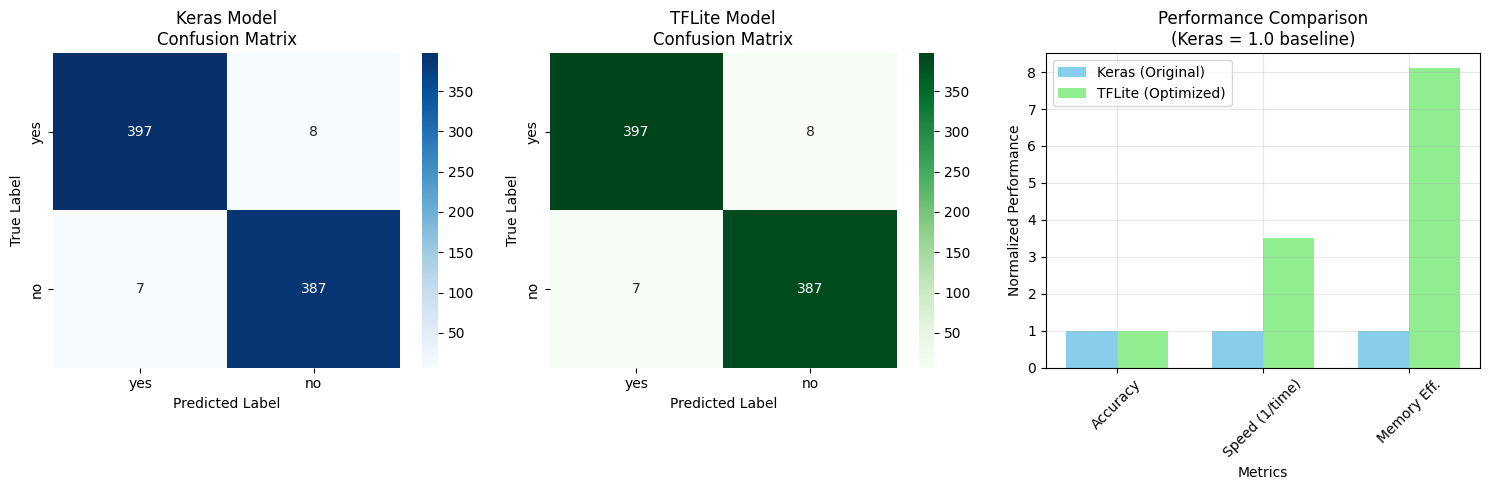


📝 NOTE:
• Speed = 1/inference_time (più alto = più veloce)
• Memory Eff. = 1/memory_used (più alto = più efficiente)
• Valori normalizzati rispetto al modello Keras originale


In [ ]:
# CELLA 7
# ========================================
# 📊 Confronto modelli: Originale vs Ottimizzato
# ========================================

import time  # Per misurare i tempi di inferenza
import psutil  # Per monitorare l'uso della memoria
import os  # Per verificare le dimensioni dei file

print("🔄 Preparazione dati di test...")
# Prepara i dati di test senza le predizioni del teacher (solo per valutazione)
test_audio_data = []
test_labels_clean = []
for i, path in enumerate(test_files):
    audio = load_and_preprocess_audio(path)  # Preprocessa l'audio di test
    test_audio_data.append(audio)  # Aggiunge l'audio processato
    test_labels_clean.append(test_labels[i])  # Aggiunge l'etichetta numerica

# Converte in array numpy per efficienza computazionale
test_audio_array = np.array(test_audio_data)
test_labels_array = np.array(test_labels_clean)
# Converte le etichette numeriche in formato one-hot per la valutazione
test_labels_onehot = tf.keras.utils.to_categorical(test_labels_array, NUM_CLASSES)

print(f"📈 Dataset di test: {len(test_audio_array)} campioni")
print("\n" + "="*60)
print("🧠 VALUTAZIONE MODELLO ORIGINALE (KERAS)")
print("="*60)

# Misura l'uso della memoria prima dell'inferenza
memory_before = psutil.Process().memory_info().rss / 1024 / 1024  # Converti in MB

# Misura il tempo di inferenza per il modello Keras originale
start_time = time.time()
keras_predictions = student_model.predict(test_audio_array, batch_size=BATCH_SIZE, verbose=0)
keras_inference_time = time.time() - start_time

# Misura l'uso della memoria dopo l'inferenza
memory_after = psutil.Process().memory_info().rss / 1024 / 1024

# Calcola le metriche per il modello Keras
keras_pred_labels = np.argmax(keras_predictions, axis=1)  # Converte probabilità in etichette
keras_accuracy = np.mean(keras_pred_labels == test_labels_array)  # Calcola accuratezza
keras_conf_matrix = confusion_matrix(test_labels_array, keras_pred_labels)  # Matrice di confusione

print(f"⏱️  Tempo inferenza: {keras_inference_time:.4f} secondi")
print(f"📊 Accuratezza: {keras_accuracy:.4f} ({keras_accuracy*100:.2f}%)")
print(f"💾 Memoria utilizzata: {memory_after - memory_before:.2f} MB")
print(f"📁 Dimensione modello: N/A (modello in memoria)")

print("\n📈 Matrice di Confusione (Keras):")
print("    Pred:")
print("       Yes  No")
for i, class_name in enumerate(CLASSES):
    print(f"Vera {class_name:3s}: {keras_conf_matrix[i][0]:3d} {keras_conf_matrix[i][1]:3d}")

print("\n📋 Report Classificazione (Keras):")
print(classification_report(test_labels_array, keras_pred_labels,
                          target_names=CLASSES, digits=4))

print("\n" + "="*60)
print("📱 VALUTAZIONE MODELLO OTTIMIZZATO (TFLITE)")
print("="*60)

# Carica l'interprete TensorFlow Lite
interpreter = tf.lite.Interpreter(model_path="student_model_optimized.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()  # Dettagli dell'input
output_details = interpreter.get_output_details()  # Dettagli dell'output

# Misura l'uso della memoria prima dell'inferenza TFLite
memory_before_tflite = psutil.Process().memory_info().rss / 1024 / 1024

# Misura il tempo di inferenza per il modello TensorFlow Lite
start_time = time.time()
tflite_predictions = []

# Inferenza campione per campione (più realistica per deployment mobile)
for audio in test_audio_data:
    # Imposta l'input (aggiunge dimensione batch)
    interpreter.set_tensor(input_details[0]['index'], np.expand_dims(audio, axis=0))
    interpreter.invoke()  # Esegue l'inferenza
    # Ottiene l'output e lo aggiunge alla lista
    output = interpreter.get_tensor(output_details[0]['index'])
    tflite_predictions.append(output[0])  # Rimuove dimensione batch

tflite_inference_time = time.time() - start_time

# Misura l'uso della memoria dopo l'inferenza TFLite
memory_after_tflite = psutil.Process().memory_info().rss / 1024 / 1024

# Converte le predizioni in array numpy
tflite_predictions = np.array(tflite_predictions)
tflite_pred_labels = np.argmax(tflite_predictions, axis=1)  # Converte in etichette
tflite_accuracy = np.mean(tflite_pred_labels == test_labels_array)  # Calcola accuratezza
tflite_conf_matrix = confusion_matrix(test_labels_array, tflite_pred_labels)  # Matrice confusione

# Ottiene la dimensione del file TFLite
tflite_size = os.path.getsize("student_model_optimized.tflite") / 1024  # Converte in KB

print(f"⏱️  Tempo inferenza: {tflite_inference_time:.4f} secondi")
print(f"📊 Accuratezza: {tflite_accuracy:.4f} ({tflite_accuracy*100:.2f}%)")
print(f"💾 Memoria utilizzata: {memory_after_tflite - memory_before_tflite:.2f} MB")
print(f"📁 Dimensione modello: {tflite_size:.2f} KB")

print("\n📈 Matrice di Confusione (TFLite):")
print("    Pred:")
print("       Yes  No")
for i, class_name in enumerate(CLASSES):
    print(f"Vera {class_name:3s}: {tflite_conf_matrix[i][0]:3d} {tflite_conf_matrix[i][1]:3d}")

print("\n📋 Report Classificazione (TFLite):")
print(classification_report(test_labels_array, tflite_pred_labels,
                          target_names=CLASSES, digits=4))

print("\n" + "="*60)
print("🏆 CONFRONTO FINALE")
print("="*60)

# Calcola le differenze percentuali tra i modelli
speed_improvement = ((keras_inference_time - tflite_inference_time) / keras_inference_time) * 100
accuracy_diff = abs(keras_accuracy - tflite_accuracy) * 100
memory_diff = abs((memory_after - memory_before) - (memory_after_tflite - memory_before_tflite))

print(f"⚡ Miglioramento velocità: {speed_improvement:.1f}%")
print(f"📊 Differenza accuratezza: {accuracy_diff:.2f}%")
print(f"💾 Differenza memoria: {memory_diff:.2f} MB")
print(f"📁 Compressione modello: N/A → {tflite_size:.1f} KB")

# Analisi qualitativa dei risultati
print(f"\n🎯 RISULTATI:")
if speed_improvement > 0:
    print(f"✅ Il modello TFLite è {speed_improvement:.1f}% più veloce")
else:
    print(f"❌ Il modello TFLite è {abs(speed_improvement):.1f}% più lento")

if accuracy_diff < 2:  # Soglia del 2% per considerare le accuratezze equivalenti
    print(f"✅ Accuratezza mantenuta (differenza: {accuracy_diff:.2f}%)")
else:
    print(f"⚠️  Perdita di accuratezza significativa: {accuracy_diff:.2f}%")

print(f"✅ Modello compresso a {tflite_size:.1f} KB (pronto per mobile)")

# Visualizzazione grafica delle matrici di confusione
plt.figure(figsize=(15, 5))

# Subplot 1: Matrice confusione Keras
plt.subplot(1, 3, 1)
sns.heatmap(keras_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Keras Model\nConfusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Subplot 2: Matrice confusione TFLite
plt.subplot(1, 3, 2)
sns.heatmap(tflite_conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('TFLite Model\nConfusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Subplot 3: Confronto metriche
plt.subplot(1, 3, 3)
metrics = ['Accuracy', 'Speed (1/time)', 'Memory Eff.']
keras_values = [keras_accuracy, 1/keras_inference_time, 1/(memory_after - memory_before + 0.1)]
tflite_values = [tflite_accuracy, 1/tflite_inference_time, 1/(memory_after_tflite - memory_before_tflite + 0.1)]

# Normalizza i valori per una migliore visualizzazione
keras_norm = np.array(keras_values) / np.array(keras_values)  # Keras come baseline (1.0)
tflite_norm = np.array(tflite_values) / np.array(keras_values)  # TFLite relativo a Keras

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, keras_norm, width, label='Keras (Original)', color='skyblue')
plt.bar(x + width/2, tflite_norm, width, label='TFLite (Optimized)', color='lightgreen')

plt.xlabel('Metrics')
plt.ylabel('Normalized Performance')
plt.title('Performance Comparison\n(Keras = 1.0 baseline)')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Ottimizza il layout dei subplot
plt.show()  # Mostra i grafici

print("\n📝 NOTE:")
print("• Speed = 1/inference_time (più alto = più veloce)")
print("• Memory Eff. = 1/memory_used (più alto = più efficiente)")
print("• Valori normalizzati rispetto al modello Keras originale")


In [ ]:
# CELLA 8
# ========================================
# 🔍 Inferenza su file .wav locali
# ========================================
from google.colab import files  # Importa il modulo per upload file in Colab
uploaded = files.upload()  # Permette all'utente di caricare file audio

# Carica l'interprete TensorFlow Lite per il modello ottimizzato
interpreter = tf.lite.Interpreter(model_path="student_model_optimized.tflite")
interpreter.allocate_tensors()  # Alloca memoria per i tensori
# Ottiene gli indici per input e output del modello
input_index = interpreter.get_input_details()[0]['index']
output_index = interpreter.get_output_details()[0]['index']

# Itera attraverso ogni file caricato per fare predizioni
for fname in uploaded.keys():
    audio = load_and_preprocess_audio(fname)  # Preprocessa il file audio
    # Imposta l'input del modello (aggiunge dimensione batch con expand_dims)
    interpreter.set_tensor(input_index, np.expand_dims(audio, axis=0))
    interpreter.invoke()  # Esegue l'inferenza
    # Ottiene le predizioni dal modello
    prediction = interpreter.get_tensor(output_index)
    pred_label = np.argmax(prediction)  # Trova la classe con probabilità massima
    confidence = np.max(prediction)  # Ottiene il valore di confidenza massimo

    # ⚠️ Applichiamo una soglia di confidenza del 90%
    if confidence < 0.90:  # Se la confidenza è bassa, classifica come sconosciuto
        print(f"🔈 {fname} => suono sconosciuto (confidenza: {confidence:.2f})")
    else:  # Altrimenti, mostra la predizione con alta confidenza
        print(f"🔈 {fname} => {CLASSES[pred_label]} (confidenza: {confidence:.2f})")

Saving yes_1.wav to yes_1 (1).wav
🔈 yes_1 (1).wav => suono sconosciuto (confidenza: 0.79)
